# Loading data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [2]:
def importdata():
    balance_data = pd.read_csv("breastcancerdata.csv")
    print("Dataset Length:", len(balance_data))
    print("Dataset Shape:", balance_data.shape)
    print("Dataset Head:\n", balance_data.head())
    return balance_data

In [3]:
data = importdata()
print(data.isnull().sum())

Dataset Length: 569
Dataset Shape: (569, 33)
Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

  

# Functions 

In [4]:
def splitdataset(balance_data):
    Y = balance_data["diagnosis"].map({"M": 1, "B": 0}).values
    X = balance_data.drop(columns=["id", "diagnosis"], errors="ignore").values
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100, stratify=Y)
    return X, Y, X_train, X_test, y_train, y_test

In [24]:
#def train_using_gini(X_train, y_train):
    #clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=3, 
                                      min_samples_leaf=5)
    #clf_gini.fit(X_train, y_train)
    #return clf_gini

In [28]:
#def train_using_entropy(X_train, y_train):
    #clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, 
                                         min_samples_leaf=5)
    #clf_entropy.fit(X_train, y_train)
    #return clf_entropy

In [5]:
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted Values:\n", y_pred)
    return y_pred

In [6]:
def cal_accuracy(y_test, y_pred):
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nAccuracy:", accuracy_score(y_test, y_pred) * 100)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [7]:
def plot_decision_tree(clf_object, feature_names, class_names):
    plt.figure(figsize=(15, 10))
    plot_tree(clf_object, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
    plt.show()

# Model training and evaluation

In [13]:
data = importdata()
X, Y, X_train, X_test, y_train, y_test = splitdataset(data)

#param_grid = {
  #  "max_depth": [2, 3, 4, 5, None],
 #   "min_samples_leaf": [1, 3, 5, 10]
#}


param_grid = {
    "max_depth": [3, 5, 8, 10, 12, None],
    "min_samples_split": [2, 10, 50, 200],
    "min_samples_leaf": [1, 5, 20, 50],
    "ccp_alpha": [0.0, 0.0001, 0.001],  # cost-complexity pruning
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_gini = GridSearchCV(
    DecisionTreeClassifier(criterion="gini", random_state=100),
    param_grid=param_grid,
    #cv=5,
    cv=cv,
    n_jobs=-1,
    scoring="accuracy",
)

grid_gini.fit(X_train, y_train)

print("Best Gini parameters:", grid_gini.best_params_)
print("Best Gini CV score:", grid_gini.best_score_)

clf_gini = grid_gini.best_estimator_

print("Gini depth:", clf_gini.get_depth())
print("Gini leaves:", clf_gini.get_n_leaves())


  
print("\n Training Using Gini ")
#clf_gini = train_using_gini(X_train, y_train)
y_pred_gini = prediction(X_test, clf_gini)
cal_accuracy(y_test, y_pred_gini)

grid_entropy = GridSearchCV(
    DecisionTreeClassifier(criterion= "entropy", random_state=100),
    param_grid=param_grid,
    #cv=5,
    cv=cv,
    n_jobs=-1,
    scoring="accuracy"
)

grid_entropy.fit(X_train, y_train)

print("Best Entropy parameters:", grid_entropy.best_params_)
print("Best Entropy CV score:", grid_entropy.best_score_)


clf_entropy = grid_entropy.best_estimator_

print("Entropy depth:", clf_entropy.get_depth())
print("Entropy leaves:", clf_entropy.get_n_leaves())
    
print("\n Training Using Entropy ")
#clf_entropy = train_using_entropy(X_train, y_train)
y_pred_entropy = prediction(X_test, clf_entropy)
cal_accuracy(y_test, y_pred_entropy)


Dataset Length: 569
Dataset Shape: (569, 33)
Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

  

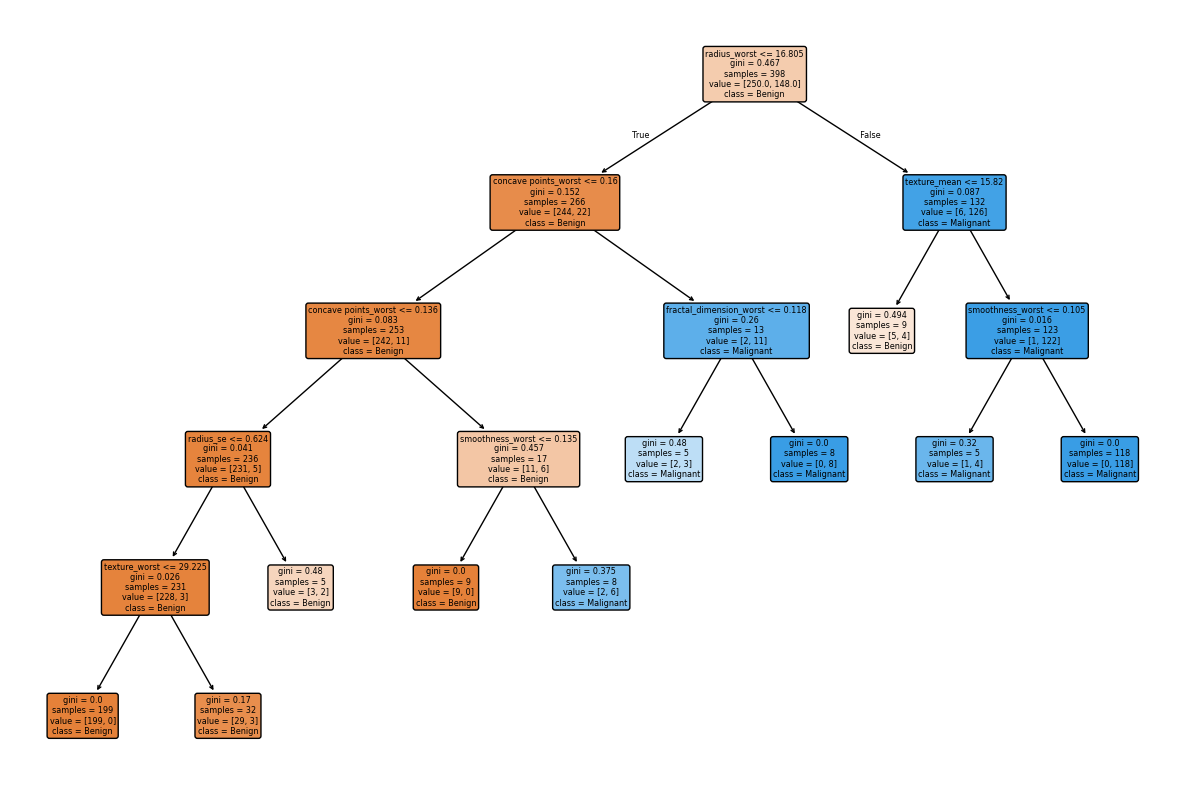

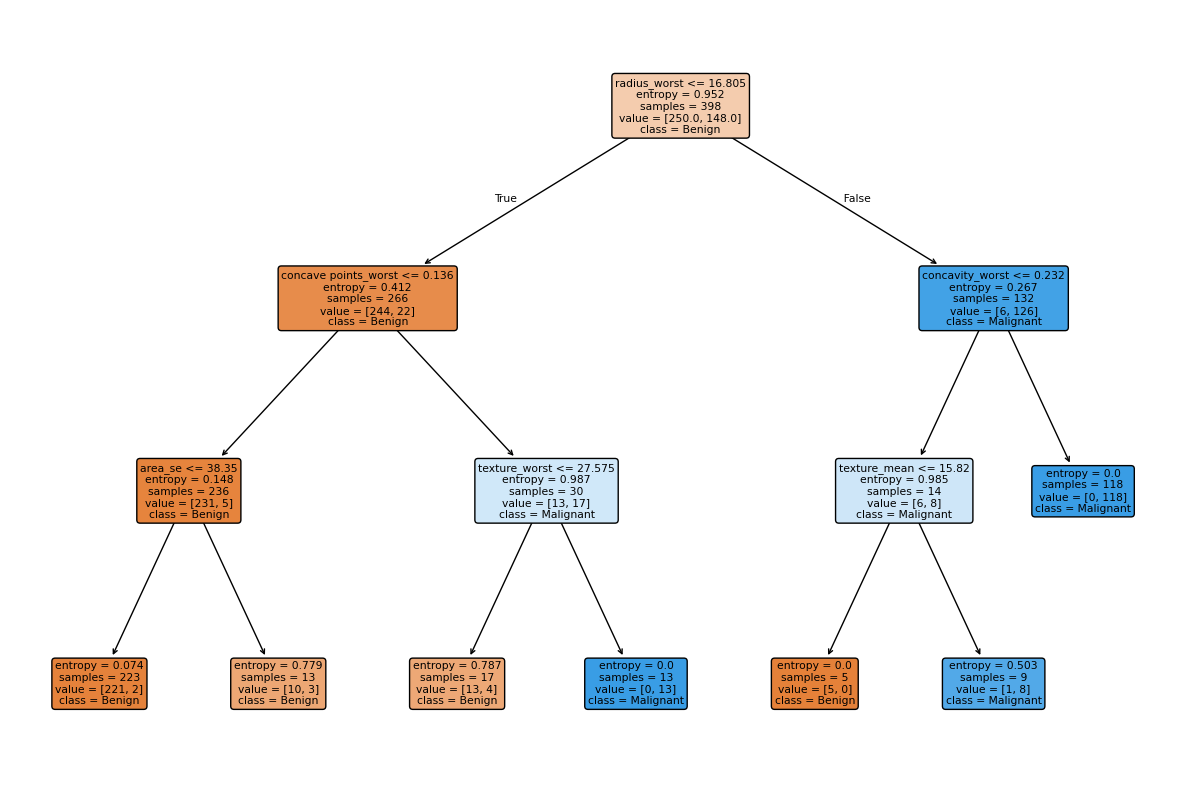

In [14]:
feature_names = data.drop(columns=["id", "diagnosis"], errors="ignore").columns
class_names = ["Benign", "Malignant"]

plot_decision_tree(clf_gini, feature_names, class_names)
plot_decision_tree(clf_entropy, feature_names, class_names)

# CV Gini

In [15]:
scores_Gini = cross_val_score(clf_gini, X_train, y_train, cv=cv, scoring="accuracy")

print("Mean CV accuracy:", scores_Gini.mean())
print("Test Accuracy gini :", clf_gini.score(X_test, y_test))
print("Gap:",  scores_Gini.mean() - clf_gini.score(X_test, y_test))
print("Std:", scores_Gini.std())

Mean CV accuracy: 0.9345253164556961
Test Accuracy gini : 0.935672514619883
Gap: -0.0011471981641868467
Std: 0.029473970711923418


# CV Entropy

In [16]:
scores_entropy = cross_val_score(clf_entropy, X_train, y_train, cv=cv, scoring="accuracy")

print("Mean CV accuracy:", scores_entropy .mean())
print("Test Accuracy entropy :", clf_entropy.score(X_test, y_test))
print("Gap:",  scores_entropy .mean() - clf_entropy.score(X_test, y_test))
print("Std:", scores_entropy .std())

Mean CV accuracy: 0.9320886075949367
Test Accuracy entropy : 0.9298245614035088
Gap: 0.0022640461914279486
Std: 0.023508505178650933


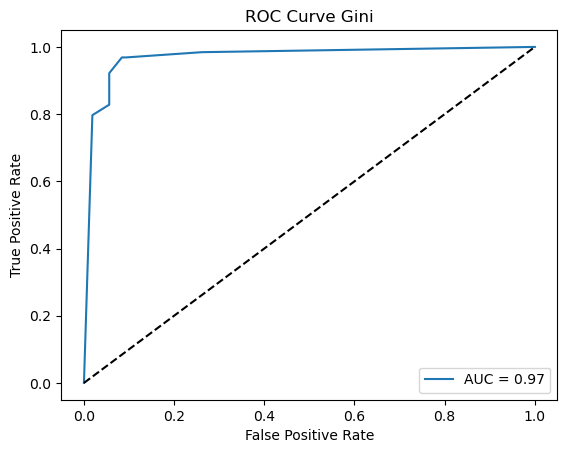

In [17]:
from sklearn.metrics import roc_curve, auc

y_probs = clf_gini.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Gini")
plt.legend()
plt.show()

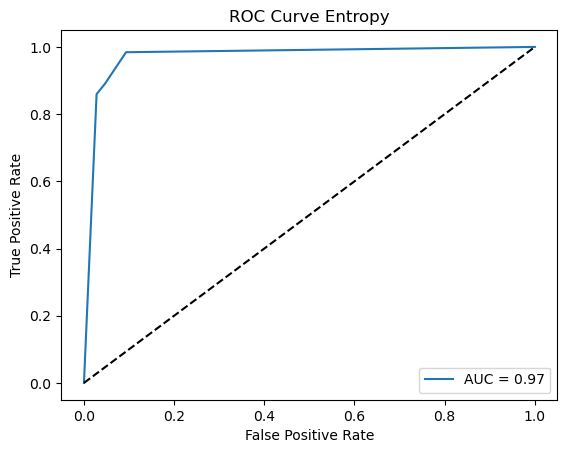

In [18]:
from sklearn.metrics import roc_curve, auc

y_probs = clf_entropy.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Entropy")
plt.legend()
plt.show()

# Without grid search

In [24]:
data = importdata()
X, Y, X_train, X_test, y_train, y_test = splitdataset(data)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\nTraining Using Gini")

clf_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=100
)

clf_gini.fit(X_train, y_train)
print("Gini depth:", clf_gini.get_depth())
print("Gini leaves:", clf_gini.get_n_leaves())


y_pred_gini = clf_gini.predict(X_test)
cal_accuracy(y_test, y_pred_gini)


print("\nTraining Using Entropy")

clf_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=100
)

clf_entropy.fit(X_train, y_train)
print("Entropy depth:", clf_entropy.get_depth())
print("Entropy leaves:", clf_entropy.get_n_leaves())

y_pred_entropy = clf_entropy.predict(X_test)
cal_accuracy(y_test, y_pred_entropy)

Dataset Length: 569
Dataset Shape: (569, 33)
Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

  

# CV Gini

In [26]:
scores_gini = cross_val_score(clf_gini, X_train, y_train, cv=cv, scoring="accuracy")

print("Entropy Mean CV accuracy:", scores_gini.mean())
print("Entropy Test accuracy:", clf_gini.score(X_test, y_test))
print("Entropy Gap:", scores_gini.mean() - clf_gini.score(X_test, y_test))
print("Entropy Std:", scores_gini.std())


Entropy Mean CV accuracy: 0.9345253164556961
Entropy Test accuracy: 0.935672514619883
Entropy Gap: -0.0011471981641868467
Entropy Std: 0.029473970711923418


# CV entropy

In [27]:
scores_entropy = cross_val_score(clf_entropy, X_train, y_train, cv=cv, scoring="accuracy")

print("Entropy Mean CV accuracy:", scores_entropy.mean())
print("Entropy Test Accuracy:", clf_entropy.score(X_test, y_test))
print("Entropy Gap:", scores_entropy.mean() - clf_entropy.score(X_test, y_test))
print("Entropy Std:", scores_entropy.std())

Entropy Mean CV accuracy: 0.9295569620253165
Entropy Test Accuracy: 0.935672514619883
Entropy Gap: -0.006115552594566531
Entropy Std: 0.022297307565972094


Gini AUC: 0.9702102803738317
Entropy AUC: 0.9641501168224299


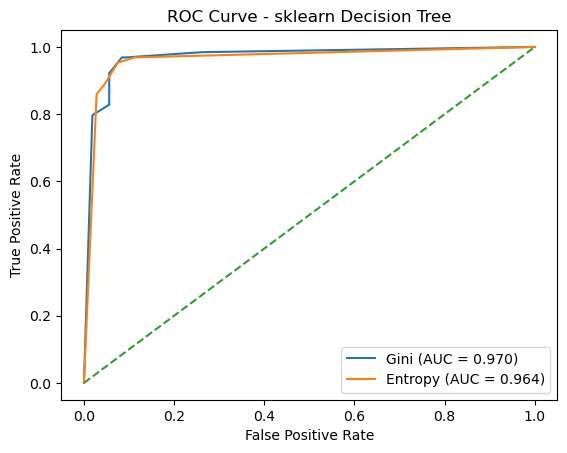

In [28]:
# --- Gini ---
y_proba_gini = clf_gini.predict_proba(X_test)[:, 1]
fpr_gini, tpr_gini, _ = roc_curve(y_test, y_proba_gini)
auc_gini = auc(fpr_gini, tpr_gini)

print("Gini AUC:", auc_gini)

# --- Entropy ---
y_proba_entropy = clf_entropy.predict_proba(X_test)[:, 1]
fpr_entropy, tpr_entropy, _ = roc_curve(y_test, y_proba_entropy)
auc_entropy = auc(fpr_entropy, tpr_entropy)

print("Entropy AUC:", auc_entropy)

# --- Plot both ---
plt.figure()

plt.plot(fpr_gini, tpr_gini, label=f"Gini (AUC = {auc_gini:.3f})")
plt.plot(fpr_entropy, tpr_entropy, label=f"Entropy (AUC = {auc_entropy:.3f})")

# baseline
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - sklearn Decision Tree")
plt.legend()

plt.show()

# Most important features gini

In [34]:
feature_names = data.drop(columns=["id", "diagnosis"], errors="ignore").columns

importance = clf_gini.feature_importances_

feat_imp_gini = pd.Series(importance, index=feature_names)
feat_imp_sorted_gini = feat_imp_gini.sort_values(ascending=False)

print(feat_imp_sorted_gini.head(10))

radius_worst               0.804777
concave points_worst       0.116554
smoothness_worst           0.030894
texture_mean               0.030162
radius_se                  0.008797
fractal_dimension_worst    0.005908
texture_worst              0.002908
radius_mean                0.000000
concave points_se          0.000000
symmetry_worst             0.000000
dtype: float64


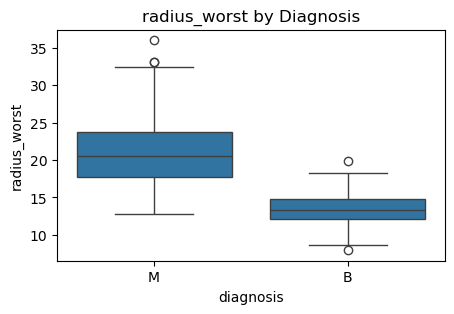

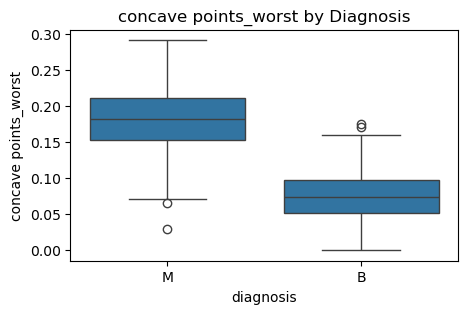

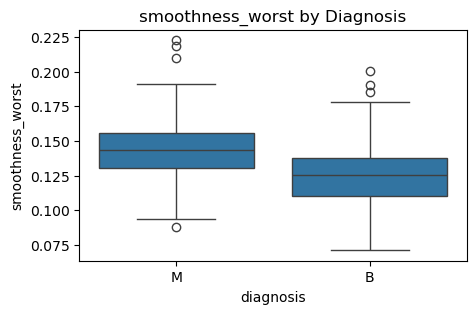

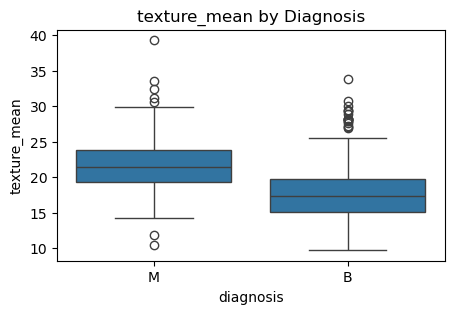

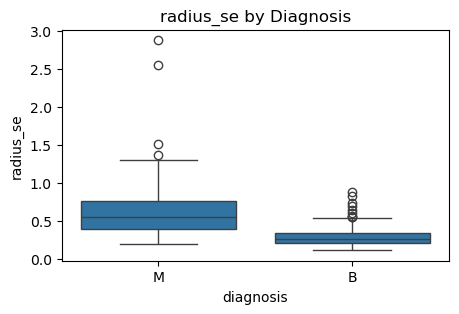

In [35]:
top_features_gini = feat_imp_sorted_gini.head(5).index

for feature in top_features_gini:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="diagnosis", y=feature, data=data)
    plt.title(f"{feature} by Diagnosis")
    plt.show()

# Most important features entropy

In [36]:
feature_names = data.drop(columns=["id","diagnosis"], errors="ignore").columns

importance_entropy = clf_entropy.feature_importances_

feat_imp_entropy = pd.Series(importance_entropy, index=feature_names)
feat_imp_entropy_sorted = feat_imp_entropy.sort_values(ascending=False)

print(feat_imp_entropy_sorted.head(10))

radius_worst            0.659748
concave points_worst    0.126596
texture_worst           0.063157
concavity_worst         0.060335
texture_mean            0.026094
area_se                 0.023476
smoothness_worst        0.018266
fractal_dimension_se    0.011638
area_worst              0.010691
radius_mean             0.000000
dtype: float64


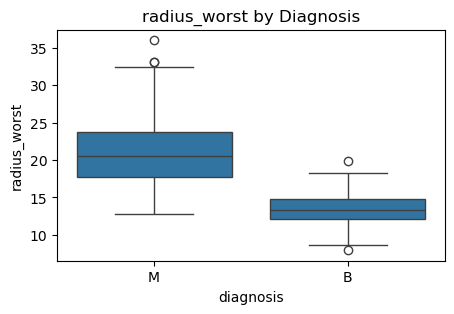

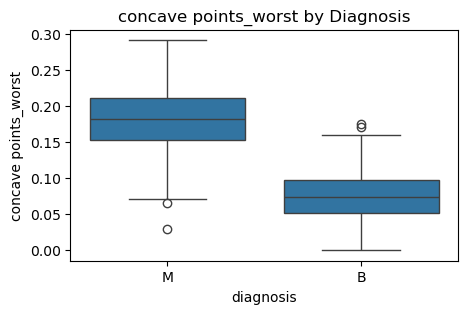

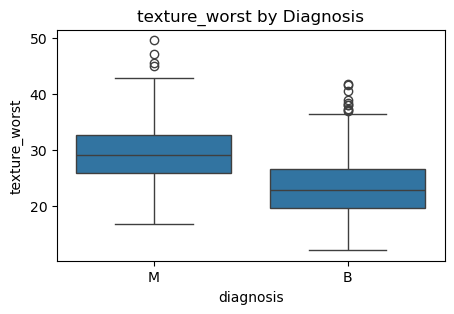

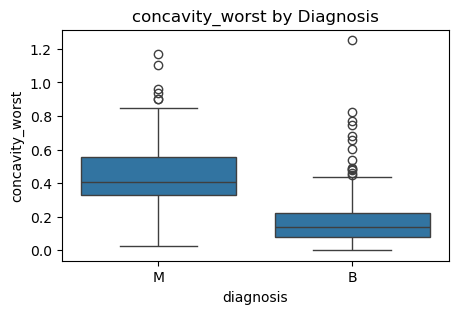

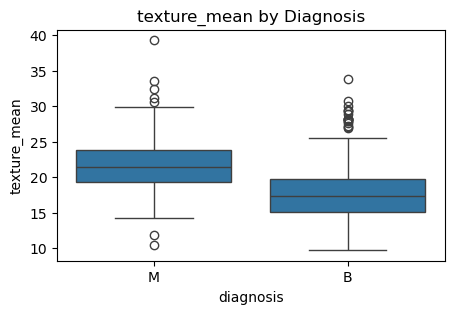

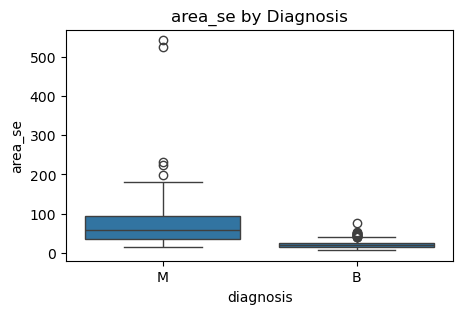

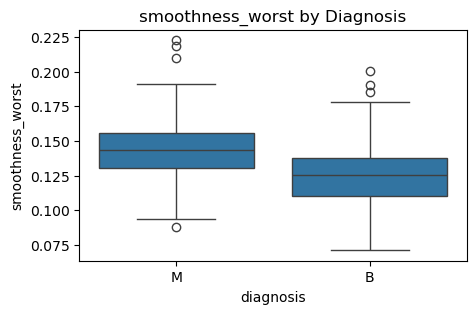

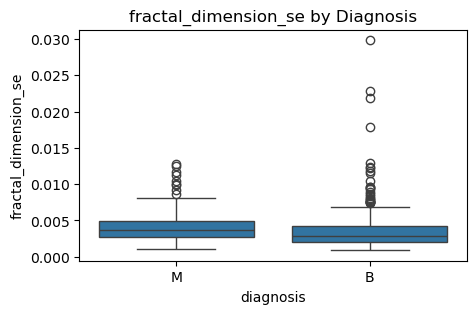

In [37]:
top_features_entropy= feat_imp_entropy_sorted.head(8).index

for feature in top_features_entropy:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="diagnosis", y=feature, data=data)
    plt.title(f"{feature} by Diagnosis")
    plt.show()

# Numpy

In [40]:
import numpy as np

class _Node:
    __slots__ = ("feature", "threshold", "left", "right", "is_leaf","proba", "pred")
    def __init__(self, *, feature=None, threshold=None, left=None, right=None,
                 is_leaf=False, proba=None, pred=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.is_leaf = is_leaf
        self.proba = proba
        self.pred = pred
    
def get_depth(node):
    if node is None or node.is_leaf:
        return 0
    return 1 + max(get_depth(node.left), get_depth(node.right))

def count_leaves(node):
    if node is None:
        return 0
    if node.is_leaf:
        return 1
    return count_leaves(node.left) + count_leaves(node.right)

In [41]:
class NumpyTreeClassifier:
    """
    NumPy-only decision tree for classification.

    Supports:
    - gini / entropy
    - predict / predict_proba / score
    - GridSearchCV compatibility
    - feature_importances_
    """

    def __init__(
        self,
        criterion="gini",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        min_gain=0.0,
        ccp_alpha=0.0,
        random_state=None
    
    ):
        if criterion not in ("gini", "entropy"):
            raise ValueError("criterion must be either 'gini' or 'entropy'")

        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = int(min_samples_split)
        self.min_samples_leaf = int(min_samples_leaf)
        self.min_gain = float(min_gain)
        self.ccp_alpha = float(ccp_alpha) 
        self.random_state = random_state

        self.classes_ = None
        self.n_classes_ = None
        self.n_features_in_ = None
        self.root_ = None
        self.feature_importances_ = None


    def get_params(self, deep=True):
        return {
            "criterion": self.criterion,
            "max_depth": self.max_depth,
            "min_samples_split": self.min_samples_split,
            "min_samples_leaf": self.min_samples_leaf,
            "min_gain": self.min_gain,
            "ccp_alpha": self.ccp_alpha,
            "random_state": self.random_state
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.n_features_in_ = X.shape[1]
        self.classes_, y_enc = np.unique(y, return_inverse=True)
        self.n_classes_ = len(self.classes_)

        self.feature_importances_ = np.zeros(self.n_features_in_, dtype=float)

        self.root_ = self._grow(X, y_enc, depth=0)

        total = self.feature_importances_.sum()
        if total > 0:
            self.feature_importances_ /= total

        return self

    def predict(self, X):
        X = np.asarray(X)
        preds_enc = np.array([self._predict_one(x, self.root_) for x in X], dtype=int)
        return self.classes_[preds_enc]

    def predict_proba(self, X):
        X = np.asarray(X)
        out = np.zeros((X.shape[0], self.n_classes_), dtype=float)

        for i, x in enumerate(X):
            node = self.root_
            while not node.is_leaf:
                if x[node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            out[i] = node.proba

        return out

    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)


    def _impurity_from_counts(self, counts):
        n = counts.sum()
        if n <= 0:
            return 0.0

        p = counts / n

        if self.criterion == "gini":
            return 1.0 - np.sum(p * p)

        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    def _best_split(self, X, y):
        n, d = X.shape

        if n < self.min_samples_split:
            return None, None, None, 0.0

        parent_counts = np.bincount(y, minlength=self.n_classes_)
        parent_impurity = self._impurity_from_counts(parent_counts)

        if parent_impurity == 0.0:
            return None, None, None, 0.0

        best_gain = 0.0
        best_feat = None
        best_thr = None

        for j in range(d):
            xj = X[:, j]

            order = np.argsort(xj, kind="quicksort")
            x_sorted = xj[order]
            y_sorted = y[order]

            # skip constant feature
            if x_sorted[0] == x_sorted[-1]:
                continue

            left_counts = np.zeros(self.n_classes_, dtype=int)
            right_counts = parent_counts.copy()

            for i in range(0, n - 1):
                c = y_sorted[i]
                left_counts[c] += 1
                right_counts[c] -= 1

                left_n = i + 1
                right_n = n - left_n

                if left_n < self.min_samples_leaf or right_n < self.min_samples_leaf:
                    continue

                # only split between distinct consecutive values
                if x_sorted[i] == x_sorted[i + 1]:
                    continue

                left_imp = self._impurity_from_counts(left_counts)
                right_imp = self._impurity_from_counts(right_counts)

                weighted_imp = (left_n / n) * left_imp + (right_n / n) * right_imp
                gain = parent_impurity - weighted_imp

                if gain > best_gain:
                    best_gain = gain
                    best_feat = j
                    best_thr = 0.5 * (x_sorted[i] + x_sorted[i + 1])

        if best_feat is None or best_gain <= self.min_gain:
            return None, None, None, 0.0

        mask = X[:, best_feat] <= best_thr
        
        if mask.sum() == 0 or mask.sum() == n:
            return None, None, None, 0.0
        
        return best_feat, best_thr, mask, best_gain

    def _grow(self, X, y, depth):
        counts = np.bincount(y, minlength=self.n_classes_)
        n = y.size

    
        if n == 0:
            return _Node(is_leaf=True, proba=np.zeros(self.n_classes_), pred=0)
       

        proba = counts / n
        pred = int(np.argmax(counts))
        impurity = self._impurity_from_counts(counts)


        if (
            (self.max_depth is not None and depth >= self.max_depth)
            or (n < self.min_samples_split)
            or (impurity == 0.0)
        ):
            return _Node(is_leaf=True, proba=proba, pred=pred)

        feat, thr, mask, gain = self._best_split(X, y)

   
        if feat is None or mask is None:
            return _Node(is_leaf=True, proba=proba, pred=pred)

    
        if mask.sum() == 0 or mask.sum() == n:
            return _Node(is_leaf=True, proba=proba, pred=pred)


        #if gain <= 0:
            #return _Node(is_leaf=True, proba=proba, pred=pred)
         
        if gain <= max(self.min_gain, self.ccp_alpha):
            return _Node(is_leaf=True, proba=proba, pred=pred)

        self.feature_importances_[feat] += gain * n

        left = self._grow(X[mask], y[mask], depth + 1)
        right = self._grow(X[~mask], y[~mask], depth + 1)

        return _Node(
            feature=feat,
            threshold=thr,
            left=left,
            right=right,
            is_leaf=False,
            proba=proba,
            pred=pred
            )

    def _predict_one(self, x, node):
        while not node.is_leaf:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.pred

# Gini

In [42]:
data = importdata()
X, Y, X_train, X_test, y_train, y_test = splitdataset(data)

#param_grid = {
 #   "max_depth": [2, 3, 4, 5, None],
#    "min_samples_leaf": [1, 3, 5, 10]
#}

param_grid = {
    "max_depth": [3, 5, 8, 10, 12, None],
    "min_samples_split": [2, 10, 50, 200],
    "min_samples_leaf": [1, 5, 20, 50],
    "ccp_alpha": [0.0, 0.0001, 0.001],  # cost-complexity pruning
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_numpy_gini = GridSearchCV(
    NumpyTreeClassifier(criterion= "gini"),
    param_grid=param_grid,
    #cv=5,
    cv=cv,
    n_jobs=-1,
    scoring="accuracy"
)

grid_numpy_gini.fit(X_train, y_train)

print("Best Gini parameters:", grid_numpy_gini.best_params_)
print("Best Gini CV score:", grid_numpy_gini.best_score_)

best_numpy_gini = grid_numpy_gini.best_estimator_

print("NumPy Gini depth:", get_depth(best_numpy_gini.root_))
print("NumPy Gini leaves:", count_leaves(best_numpy_gini.root_))

print("\n Training Using Gini ")
y_pred_gini = prediction(X_test, best_numpy_gini)
cal_accuracy(y_test, y_pred_gini)



Dataset Length: 569
Dataset Shape: (569, 33)
Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

  

# Entropy

In [27]:
data = importdata()
X, Y, X_train, X_test, y_train, y_test = splitdataset(data)

#param_grid = {
    #"max_depth": [2, 3, 4, 5, None],
    #"min_samples_leaf": [1, 3, 5, 10]
#}
param_grid = {
    "max_depth": [3, 5, 8, 10, 12, None],
    "min_samples_split": [2, 10, 50, 200],
    "min_samples_leaf": [1, 5, 20, 50],
    "ccp_alpha": [0.0, 0.0001, 0.001],  # cost-complexity pruning
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_numpy_entropy = GridSearchCV(
    NumpyTreeClassifier(criterion= "entropy"),
    param_grid=param_grid,
    #cv=5,
    cv=cv,
    n_jobs=-1,
    scoring="accuracy"
)

grid_numpy_entropy.fit(X_train, y_train)

print("Best Entropy parameters:", grid_numpy_entropy.best_params_)
print("Best Entropy CV score:", grid_numpy_entropy.best_score_)

best_numpy_entropy = grid_numpy_entropy.best_estimator_

print("NumPy Entropy depth:", get_depth(best_numpy_entropy.root_))
print("NumPy Entropy leaves:", count_leaves(best_numpy_entropy.root_))
    
print("\n Training Using Entropy ")
y_pred_entropy = prediction(X_test, best_numpy_entropy)
cal_accuracy(y_test, y_pred_entropy)

Dataset Length: 569
Dataset Shape: (569, 33)
Dataset Head:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

  

# Gini

In [28]:
scores_best_numpy_gini = cross_val_score(best_numpy_gini, X_train, y_train, cv=cv, scoring="accuracy")

print("Mean CV accuracy:", scores_best_numpy_gini.mean())
print("Test Accuracy gini :", grid_numpy_gini.score(X_test, y_test))
print("Gap:",  scores_best_numpy_gini.mean() - grid_numpy_gini.score(X_test, y_test))
print("Std:", scores_best_numpy_gini.std())

Mean CV accuracy: 0.9345569620253164
Test Accuracy gini : 0.9473684210526315
Gap: -0.012811459027315175
Std: 0.0260115417543519


# 80/20

Mean CV accuracy: 0.9428571428571428
Test Accuracy gini : 0.9035087719298246
Gap: 0.039348370927318244
Std: 0.010766987880365607

# Entropy

In [29]:
scores_best_numpy_entropy = cross_val_score(best_numpy_entropy, X_train, y_train, cv=cv, scoring="accuracy")

print("Mean CV accuracy:", scores_best_numpy_entropy.mean())
print("Test Accuracy gini :", grid_numpy_entropy.score(X_test, y_test))
print("Gap:",  scores_best_numpy_entropy.mean() - grid_numpy_entropy.score(X_test, y_test))
print("Std:", scores_best_numpy_entropy.std())

Mean CV accuracy: 0.9320886075949367
Test Accuracy gini : 0.9298245614035088
Gap: 0.0022640461914279486
Std: 0.023508505178650933


# 80/20

Mean CV accuracy: 0.9494505494505494
Test Accuracy gini : 0.9035087719298246
Gap: 0.045941777520724814
Std: 0.03154439581188423

# Top 10 Gini

In [30]:
feature_names = data.drop(columns=["id", "diagnosis"], errors="ignore").columns

importance = best_numpy_gini.feature_importances_

feat_imp_gini = pd.Series(importance, index=feature_names)
feat_imp_sorted_gini = feat_imp_gini.sort_values(ascending=False)

print(feat_imp_sorted_gini.head(10))

radius_worst               0.796512
concave points_worst       0.115357
texture_mean               0.029852
smoothness_mean            0.026396
texture_worst              0.020101
smoothness_worst           0.011782
radius_mean                0.000000
concave points_se          0.000000
fractal_dimension_worst    0.000000
symmetry_worst             0.000000
dtype: float64


# Top 10 Entropy

In [31]:
importance_entropy = best_numpy_entropy.feature_importances_

feat_imp_entropy = pd.Series(importance_entropy, index=feature_names)
feat_imp_sorted_entropy = feat_imp_entropy.sort_values(ascending=False)

print(feat_imp_sorted_entropy.head(10))

radius_worst               0.700389
concave points_worst       0.134394
concavity_worst            0.064051
texture_worst              0.048541
texture_mean               0.027702
area_se                    0.024922
radius_mean                0.000000
concave points_se          0.000000
fractal_dimension_worst    0.000000
symmetry_worst             0.000000
dtype: float64


Gini AUC: 0.9456775700934579


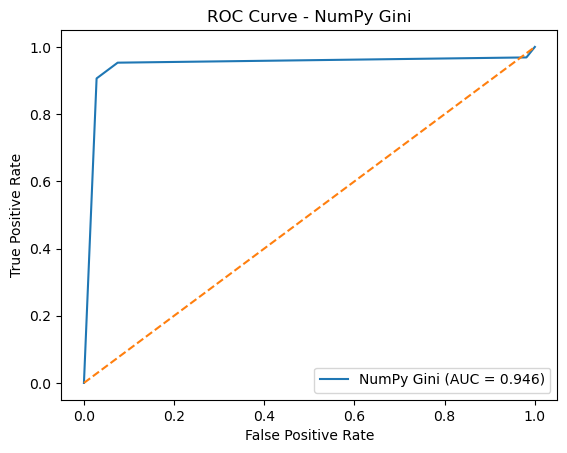

In [32]:
y_proba_gini = best_numpy_gini.predict_proba(X_test)[:, 1]

fpr_gini, tpr_gini, thresholds = roc_curve(y_test, y_proba_gini)
roc_auc_gini = auc(fpr_gini, tpr_gini)

print("Gini AUC:", roc_auc_gini)

plt.figure()
plt.plot(fpr_gini, tpr_gini, label=f"NumPy Gini (AUC = {roc_auc_gini:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - NumPy Gini")
plt.legend()
plt.show()

Entropy AUC: 0.9715975467289719


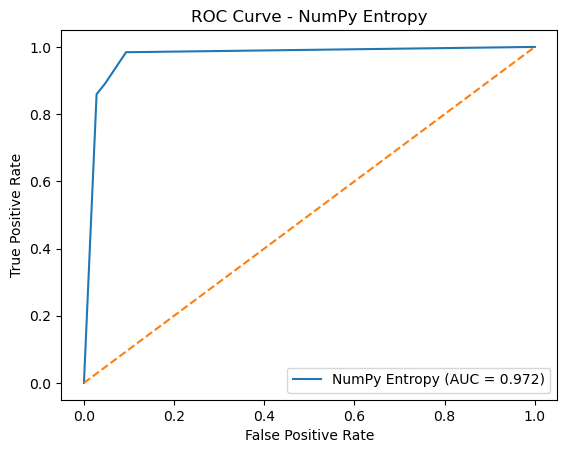

In [33]:
y_proba_entropy = best_numpy_entropy.predict_proba(X_test)[:, 1]

fpr_entropy, tpr_entropy, thresholds = roc_curve(y_test, y_proba_entropy)
roc_auc_entropy = auc(fpr_entropy, tpr_entropy)

print("Entropy AUC:", roc_auc_entropy)

plt.figure()
plt.plot(fpr_entropy, tpr_entropy, label=f"NumPy Entropy (AUC = {roc_auc_entropy:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - NumPy Entropy")
plt.legend()
plt.show()

# No grid search

# Gini

In [71]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_numpy_gini = NumpyTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    ccp_alpha=0.0
)

clf_numpy_gini.fit(X_train, y_train)

y_pred_gini = clf_numpy_gini.predict(X_test)

print("NumPy Gini depth:", get_depth(clf_numpy_gini.root_))
print("NumPy Gini leaves:", count_leaves(clf_numpy_gini.root_))

cal_accuracy(y_test, y_pred_gini)

scores_gini = cross_val_score(
    clf_numpy_gini,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

NumPy Gini depth: 5
NumPy Gini leaves: 10

Confusion Matrix:
 [[101   6]
 [  5  59]]

Accuracy: 93.56725146198829

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       107
           1       0.91      0.92      0.91        64

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



In [72]:
print("NumPy Gini Mean CV accuracy:", scores_gini.mean())
print("NumPy Gini Test accuracy:", clf_numpy_gini.score(X_test, y_test))
print("NumPy Gini Gap:", scores_gini.mean() - clf_numpy_gini.score(X_test, y_test))
print("NumPy Gini Std:", scores_gini.std())


NumPy Gini Mean CV accuracy: 0.929525316455696
NumPy Gini Test accuracy: 0.935672514619883
NumPy Gini Gap: -0.006147198164186962
NumPy Gini Std: 0.023748012844957818


AUC: 0.9724007009345794


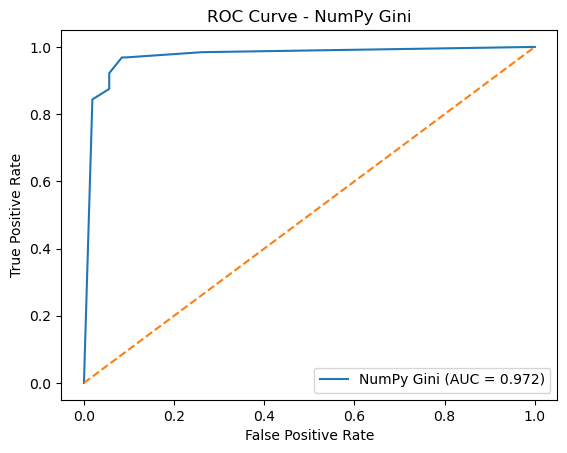

In [67]:
y_proba = clf_numpy_gini.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"NumPy Gini (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - NumPy Gini")
plt.legend()

plt.show()

# Entropy 

In [62]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


clf_numpy_entropy = NumpyTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    ccp_alpha=0.0
)

clf_numpy_entropy.fit(X_train, y_train)

y_pred_entropy = clf_numpy_entropy.predict(X_test)

print("NumPy Entropy depth:", get_depth(clf_numpy_entropy.root_))
print("NumPy Entropy leaves:", count_leaves(clf_numpy_entropy.root_))

cal_accuracy(y_test, y_pred_entropy)

scores_entropy = cross_val_score(
    clf_numpy_entropy,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

NumPy Entropy depth: 4
NumPy Entropy leaves: 10

Confusion Matrix:
 [[99  8]
 [ 3 61]]

Accuracy: 93.56725146198829

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       107
           1       0.88      0.95      0.92        64

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.93       171
weighted avg       0.94      0.94      0.94       171



In [63]:
print("NumPy Entropy Mean CV accuracy:", scores_entropy.mean())
print("NumPy Entropy Test accuracy:", clf_numpy_entropy.score(X_test, y_test))
print("NumPy Entropy Gap:", scores_entropy.mean() - clf_numpy_entropy.score(X_test, y_test))
print("NumPy Entropy Std:", scores_entropy.std())


NumPy Entropy Mean CV accuracy: 0.9270569620253164
NumPy Entropy Test accuracy: 0.935672514619883
NumPy Entropy Gap: -0.008615552594566589
NumPy Entropy Std: 0.021964852260330334


Entropy AUC: 0.9613025700934579


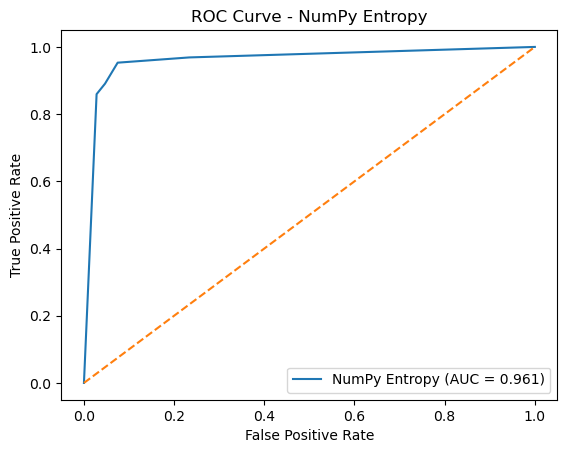

In [64]:
y_proba_entropy = clf_numpy_entropy.predict_proba(X_test)[:, 1]


fpr_e, tpr_e, _ = roc_curve(y_test, y_proba_entropy)
roc_auc_e = auc(fpr_e, tpr_e)

print("Entropy AUC:", roc_auc_e)

plt.figure()
plt.plot(fpr_e, tpr_e, label=f"NumPy Entropy (AUC = {roc_auc_e:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - NumPy Entropy")
plt.legend()

plt.show()